<a href="https://colab.research.google.com/github/chirontan/FEM/blob/FEM_NEWTON-RALPHSON/Newton_Ralphson_Method_Prob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Q1(c) — Newton–Raphson code**

In [ ]:


import numpy as np

# Residual vector R(c)
def residual(c):
    c1, c2 = c

    R1 = (c1**3)/5 + (c1**2*c2)/2 + (3*c1*c2**2)/7 \
         + c1 + (c2**3)/8 + c2 - 1/2

    R2 = (c1**3)/6 + (3*c1**2*c2)/7 + (3*c1*c2**2)/8 \
         + c1 + (c2**3)/9 + (4*c2)/3 - 1/3

    return np.array([R1, R2])


# Jacobian matrix J(c)
def jacobian(c):
    c1, c2 = c

    J11 = 1 + (3*c1**2)/5 + c1*c2 + (3*c2**2)/7

    J12 = 1 + (c1**2)/2 + (6*c1*c2)/7 + (3*c2**2)/8

    J21 = J12

    J22 = 4/3 + (3*c1**2)/7 + (3*c1*c2)/4 + (c2**2)/3

    return np.array([
        [J11, J12],
        [J21, J22]
    ])


# Initial guess
c = np.array([0.0, 0.0])

# Newton-Raphson parameters
tol = 1e-10
max_iter = 50

# Newton-Raphson iteration
for k in range(max_iter):

    R = residual(c)

    # Check convergence
    if np.linalg.norm(R, 2) < tol:
        break

    J = jacobian(c)

    # Solve J Δc = -R
    delta_c = np.linalg.solve(J, -R)

    # Update c
    c = c + delta_c


# Final solution
print("Newton-Raphson solution:")
print("c1 =", c[0])
print("c2 =", c[1])

print("\nFinal residual:")
print(residual(c))

print("\nFinal residual norm:")
print(np.linalg.norm(residual(c), 2))

Newton-Raphson solution:
c1 = 0.943061473598129
c2 = -0.47707593021137146

Final residual:
[1.33226763e-15 1.05471187e-15]

Final residual norm:
1.6992216372873033e-15


## **Q1(d) — Iteration history code**


Newton-Raphson Iteration History
---------------------------------------------------------------
 k        c1             c2          ||R||2       ||Δc||2
---------------------------------------------------------------
 0    0.0000000000    0.0000000000   6.00925e-01   1.11803e+00
 1    1.0000000000   -0.5000000000   5.25669e-02   6.06646e-02
 2    0.9437286797   -0.4773342337   6.27249e-04   7.15362e-04
 3    0.9430615664   -0.4770759660   8.75304e-08   9.94426e-08
 4    0.9430614736   -0.4770759302   1.69922e-15       -


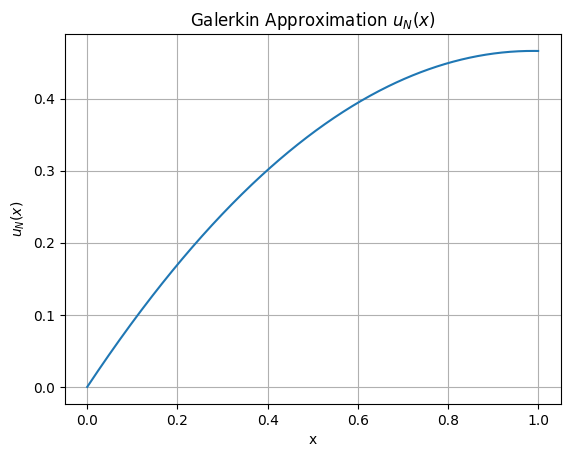

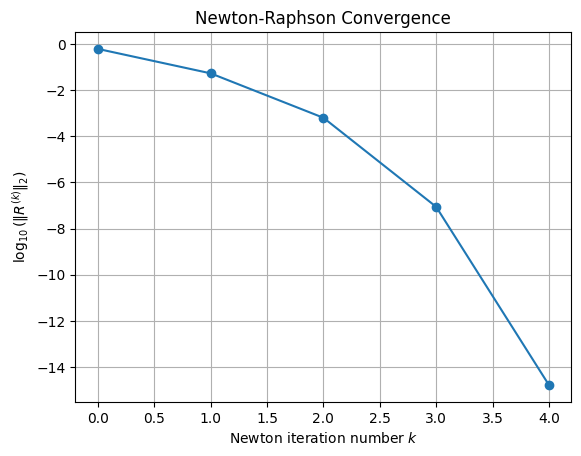

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Residual vector R(c)
# ---------------------------------------------------------
def residual(c):

    c1, c2 = c

    R1 = (
        c1**3 / 5
        + c1**2 * c2 / 2
        + 3*c1*c2**2 / 7
        + c1
        + c2**3 / 8
        + c2
        - 1/2
    )

    R2 = (
        c1**3 / 6
        + 3*c1**2*c2 / 7
        + 3*c1*c2**2 / 8
        + c1
        + c2**3 / 9
        + 4*c2 / 3
        - 1/3
    )

    return np.array([R1, R2])


# ---------------------------------------------------------
# Jacobian matrix J(c)
# ---------------------------------------------------------
def jacobian(c):

    c1, c2 = c

    J11 = (
        1
        + 3*c1**2 / 5
        + c1*c2
        + 3*c2**2 / 7
    )

    J12 = (
        1
        + c1**2 / 2
        + 6*c1*c2 / 7
        + 3*c2**2 / 8
    )

    J21 = J12

    J22 = (
        4/3
        + 3*c1**2 / 7
        + 3*c1*c2 / 4
        + c2**2 / 3
    )

    return np.array([
        [J11, J12],
        [J21, J22]
    ])


# ---------------------------------------------------------
# Initial state
# ---------------------------------------------------------
c = np.array([0.0, 0.0])

tol = 1e-10
max_iter = 50


# ---------------------------------------------------------
# Store iteration history
# ---------------------------------------------------------
history = []


# ---------------------------------------------------------
# Newton-Raphson iteration
# ---------------------------------------------------------
for k in range(max_iter):

    # Calculate residual
    R = residual(c)

    # Calculate residual norm
    Rnorm = np.linalg.norm(R, 2)

    # If converged, no new correction is calculated
    if Rnorm < tol:

        history.append([
            k,
            c[0],
            c[1],
            Rnorm,
            np.nan
        ])

        break

    # Calculate Jacobian
    J = jacobian(c)

    # Newton equation:
    # J Δc = -R
    delta_c = np.linalg.solve(J, -R)

    # Correction norm
    delta_norm = np.linalg.norm(delta_c, 2)

    # Store iteration information
    history.append([
        k,
        c[0],
        c[1],
        Rnorm,
        delta_norm
    ])

    # Update state
    c = c + delta_c


# =========================================================
# Q1(d) — PART 1: PRINT ITERATION HISTORY
# =========================================================

print("\nNewton-Raphson Iteration History")
print("---------------------------------------------------------------")
print(" k        c1             c2          ||R||2       ||Δc||2")
print("---------------------------------------------------------------")

for row in history:

    k = int(row[0])
    c1 = row[1]
    c2 = row[2]
    Rnorm = row[3]
    dnorm = row[4]

    if np.isnan(dnorm):

        print(
            f"{k:2d}   "
            f"{c1: .10f}   "
            f"{c2: .10f}   "
            f"{Rnorm:.5e}       -"
        )

    else:

        print(
            f"{k:2d}   "
            f"{c1: .10f}   "
            f"{c2: .10f}   "
            f"{Rnorm:.5e}   "
            f"{dnorm:.5e}"
        )


# =========================================================
# Q1(d) — PART 2: PLOT u_N(x)
# =========================================================

x = np.linspace(0, 1, 500)

# u_N(x) = c1*x + c2*x^2
uN = c[0]*x + c[1]*x**2

plt.figure()

plt.plot(x, uN)

plt.xlabel("x")
plt.ylabel("$u_N(x)$")
plt.title("Galerkin Approximation $u_N(x)$")

plt.grid(True)
plt.show()


# =========================================================
# Q1(d) — PART 3: PLOT RESIDUAL CONVERGENCE
# =========================================================

iteration_numbers = []
residual_norms = []

for row in history:

    iteration_numbers.append(int(row[0]))
    residual_norms.append(row[3])


plt.figure()

plt.plot(
    iteration_numbers,
    np.log10(residual_norms),
    "o-"
)

plt.xlabel("Newton iteration number $k$")
plt.ylabel(r"$\log_{10}(\|R^{(k)}\|_2)$")
plt.title("Newton-Raphson Convergence")

plt.grid(True)
plt.show()

The residual norm decreases rapidly with each Newton–Raphson iteration, from 6.01 x 10^(-1) initially to below 10^(-10) within four iterations. The rapid decrease indicates fast convergence of the Newton–Raphson method to the converged solution.

